In [1]:
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt

from evoscape.landscapes import Landscape
from evoscape.modules import Node
from evoscape.morphogen_regimes import mr_const
from evoscape.landscape_visuals import plot_traj, visualize_landscape
from evoscape.jax.experiment import Experiment
from evoscape.jax.dynamics import state_probs

plt.style.use("default")

In [2]:
modules = (
    Node(x=1.5, y=0.0, a=np.array([1.5]), s=np.array([1.0])),
    Node(x=-1.5, y=0.0, a=np.array([1.5]), s=np.array([1.0])),
)

landscape = Landscape(
    module_list=modules,
    A0=0.05,
    init_cond=(0.0, 0.0),
    regime=mr_const,
    n_regimes=1,
    morphogen_times=(),
)

experiment = Experiment(landscape)

n_cells = 200
q0 = np.vstack((
    np.linspace(-1, 1, n_cells),
    np.ones(n_cells),
))

experiment.set_initial_conditions(q0)
experiment.set_regime_params()
experiment.set_state_probs(state_probs)
experiment.set_simulation(t0=0.0, tf=3.0, nt=10, ndt=50, noise=0.2)

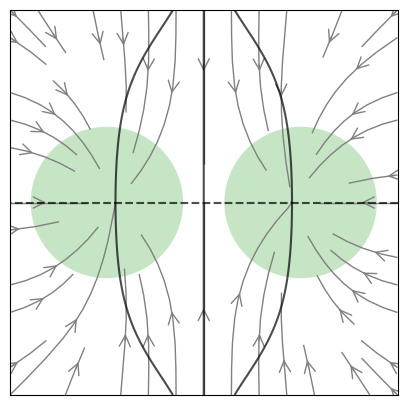

In [3]:

L = 3.
npoints = 201
q = np.linspace(-L, L, npoints)
xx, yy = np.meshgrid(q, q, indexing='xy')

fig = visualize_landscape(landscape, xx, yy, regime=0, color_scheme='fp_types')

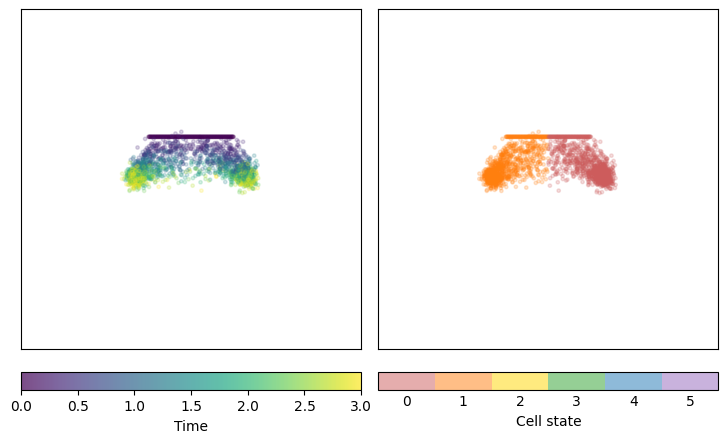

In [4]:
traj, states, t0, tf, nt = experiment.get_trajectory(seed=0)
fig = plot_traj(traj, states, t0, tf, nt, L=4)
plt.show()

In [5]:
np.mean(states[:, :, -1], axis=1)

Array([0.51025116, 0.48974884], dtype=float32)

Train step 0 : Loss = 0.0741267055273056
Train step 5 : Loss = 0.014230474829673767
Train step 10 : Loss = 0.01405487209558487
Train step 15 : Loss = 0.0018181651830673218
Train step 20 : Loss = 6.972253322601318e-05
Train step 25 : Loss = 0.0002050548791885376
Train step 30 : Loss = 3.263354301452637e-05
Train step 35 : Loss = 0.00012950599193572998
Train step 40 : Loss = 6.249547004699707e-05
Train step 45 : Loss = 0.0012103170156478882
Train step 50 : Loss = 0.004404708743095398
Train step 55 : Loss = 0.005182042717933655
Train step 60 : Loss = 0.00421568751335144
Train step 65 : Loss = 8.450448513031006e-05
Train step 70 : Loss = 1.1160969734191895e-05
Train step 75 : Loss = 0.0029675066471099854
Train step 80 : Loss = 0.0002301335334777832
Train step 85 : Loss = 5.7816505432128906e-05
Train step 90 : Loss = 0.0034815818071365356
Train step 95 : Loss = 0.0009464025497436523
Landscape with modules:
Node: x=1.600223422050476; y=0.42249414324760437; a=[1.557312]; s=[0.9697468],
Node: 

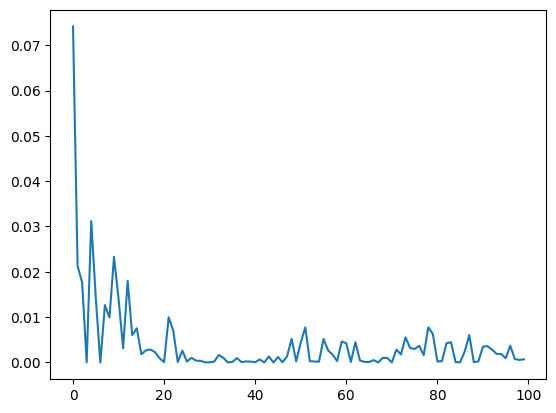

In [6]:
from evoscape.jax.losses import biseparating_fitness

def user_fitness(traj, states, dynamic, fitness_params):
    final_states = jnp.mean(states[:, :, -1], axis=1) # avg over cells

    # using target proportion 75% / 25%
    proportion_loss = jnp.sum((final_states - jnp.array((0.75, 0.25))) ** 2)

    return proportion_loss


losses = experiment.optimize(biseparating_fitness, fitness_params=(1., 0., [0.7, 0.3]), steps=100, lr=0.1, seed=0)
optimized_landscape = experiment.get_landscape()

plt.plot(losses)
print(optimized_landscape)

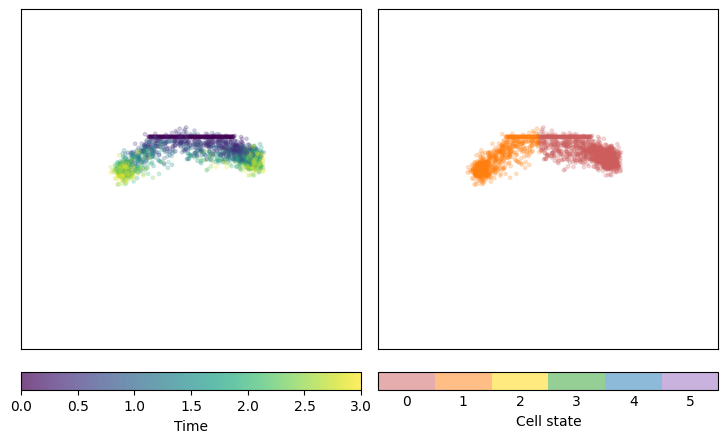

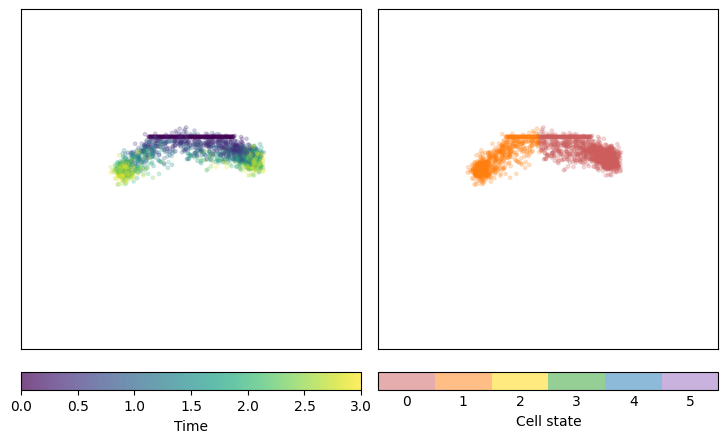

In [7]:
traj, states, t0, tf, nt = experiment.get_trajectory(seed=0)
fig = plot_traj(traj, states, t0, tf, nt, L=4)
fig

In [8]:
np.mean(states[:, :, -1], axis=1)

Array([0.68498933, 0.31501067], dtype=float32)

Landscape with modules:
Node: x=1.600223422050476; y=0.42249414324760437; a=[1.557312]; s=[0.9697468],
Node: x=-1.8355302810668945; y=0.13594286143779755; a=[1.4868753]; s=[0.8725807]


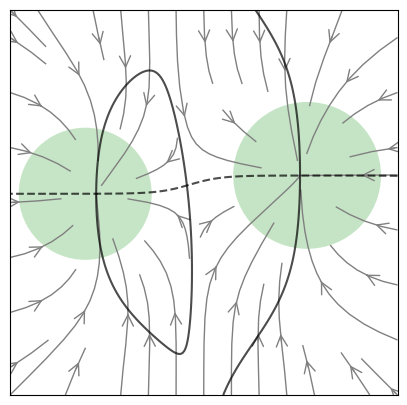

In [9]:
l = experiment.get_landscape()


print(l)

L = 3.
npoints = 201
q = np.linspace(-L, L, npoints)
xx, yy = np.meshgrid(q, q, indexing='xy')

fig = visualize_landscape(l, xx, yy, regime=0, color_scheme='fp_types')